# NHAMCS 1992–2022 — Initial Exploration

**Goal:** fetch every available year of CDC NHAMCS Emergency Department data, load them into one DataFrame, and produce baseline sex-disparity plots.

**Source:** CDC National Hospital Ambulatory Medical Care Survey, public-use files.

**Coverage caveat:** NHAMCS published Stata datasets for all years *except* 2002–2004 (those years only ship raw `.do + .dct` loaders, no packaged `.dta`). The `WAITTIME` column is only populated reliably from 1997 onward; `PAINSCALE` appears around 2004; `IMMEDR` (triage acuity) coding stabilized in the mid-2000s. Plots below only use years where the needed columns exist.

In [4]:
import io
import zipfile
from pathlib import Path

import certifi
import urllib3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../data/nhamcs")
DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE = (
    "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Dataset_Documentation/NHAMCS/stata"
)
HTTP = urllib3.PoolManager(ca_certs=certifi.where())


## 1. Download all available years

Three file naming conventions on the CDC FTP:
- `ed{YY}-stata.zip` for 1992–2001
- `ed{YYYY}-stata.exe` for 2005–2010 (self-extracting zip; Python's `zipfile` reads it fine)
- `ed{YYYY}-stata.zip` for 2011–2022

2002–2004 are skipped — no pre-built `.dta` file published for those years.

In [5]:
YEARS = [y for y in range(1992, 2023) if y not in (2002, 2003, 2004)]


def url_for(year: int) -> str:
    if year <= 2001:
        return f"{BASE}/ed{year % 100:02d}-stata.zip"
    if year == 2005:
        return f"{BASE}/ed05-stata.exe"
    if year in (2006, 2007, 2008, 2009, 2010):
        return f"{BASE}/ed{year}-stata.exe"
    return f"{BASE}/ed{year}-stata.zip"


def dta_path(year: int) -> Path:
    return DATA_DIR / f"ed{year}-stata.dta"


def ensure_year(year: int) -> Path:
    target = dta_path(year)
    if target.exists():
        return target
    url = url_for(year)
    print(f"  fetching {year}: {url.split('/')[-1]}", end=" ")
    resp = HTTP.request("GET", url, preload_content=True)
    if resp.status != 200:
        raise RuntimeError(f"HTTP {resp.status}")
    with zipfile.ZipFile(io.BytesIO(resp.data)) as zf:
        dta_name = next((n for n in zf.namelist() if n.lower().endswith(".dta")), None)
        if dta_name is None:
            raise RuntimeError(f"No .dta file in archive for {year}")
        with zf.open(dta_name) as src, open(target, "wb") as dst:
            dst.write(src.read())
    print(f"-> {target.stat().st_size / 1e6:.1f} MB")
    return target


print(f"Ensuring {len(YEARS)} years of NHAMCS ED data...")
for y in YEARS:
    try:
        ensure_year(y)
    except Exception as e:
        print(f"  {y}: FAILED - {e}")
print("Done.")


Ensuring 28 years of NHAMCS ED data...
Done.


## 2. Load all years into one DataFrame

Column naming changes across years (case, spelling). We normalize to upper-case and keep only the stable set of columns relevant to a sex-disparity story.

In [6]:
CORE_COLUMNS = [
    "SEX",
    "AGE",
    "AGER",
    "WAITTIME",
    "LOV",
    "IMMEDR",
    "PAINSCALE",
    "ARRTIME",
    "VMONTH",
    "VDAYR",
    "RFV1",
    "DIAG1",
    "ADMIT",
    "ARREMS",
    "PATWT",
]


def load_year(year: int) -> pd.DataFrame:
    df = pd.read_stata(dta_path(year), convert_categoricals=False)
    df.columns = [c.upper() for c in df.columns]
    keep = [c for c in CORE_COLUMNS if c in df.columns]
    out = df[keep].copy()
    out["YEAR"] = year
    return out


frames = []
for y in YEARS:
    try:
        frames.append(load_year(y))
    except Exception as e:
        print(f"  {y}: load failed — {e}")

data = pd.concat(frames, ignore_index=True, sort=False)
print(f"Combined: {len(data):,} visits across {data['YEAR'].nunique()} years")
print(f"Years loaded: {sorted(data['YEAR'].unique())}")

Combined: 725,593 visits across 28 years
Years loaded: [np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [7]:
def columns_for(year):
    with pd.io.stata.StataReader(dta_path(year), convert_categoricals=False) as r:
        return {col.upper() for col in r.read(1).columns}


year_cols = {y: columns_for(y) for y in YEARS}
coverage = pd.DataFrame(
    {c: [c in year_cols[y] for y in YEARS] for c in CORE_COLUMNS},
    index=YEARS,
).astype(int)

print("Column availability by year (1 = present):")
coverage[["SEX", "AGE", "WAITTIME", "IMMEDR", "PAINSCALE", "DIAG1", "PATWT"]]

Column availability by year (1 = present):


,SEX,AGE,WAITTIME,IMMEDR,PAINSCALE,DIAG1,PATWT
1992,1,1,0,0,0,1,1
1993,1,1,0,0,0,1,1
1994,1,1,0,0,0,1,1
1995,1,1,0,0,0,1,1
1996,1,1,0,0,0,1,1
1997,1,1,1,0,0,1,1
1998,1,1,1,0,0,1,1
1999,1,1,1,0,0,1,1
2000,1,1,1,0,0,1,1
2001,1,1,0,0,0,1,1


## 3. Clean key fields

NHAMCS uses negative sentinel values (`-9`, `-8`, `-7`) for missing / not applicable. Replace with `NaN` on the numeric columns.

In [8]:
data["sex_label"] = data["SEX"].map({1: "Female", 2: "Male"})

for col in ["WAITTIME", "LOV", "PAINSCALE", "IMMEDR"]:
    if col in data.columns:
        data.loc[data[col] < 0, col] = np.nan

print(f"Total visits: {len(data):,}")
print(f"Share female: {(data['sex_label'] == 'Female').mean():.1%}")
print(f"Share with valid WAITTIME: {data['WAITTIME'].notna().mean():.1%}")

Total visits: 725,593
Share female: 53.5%
Share with valid WAITTIME: 68.2%


## 4. Plot — Sampled visits by sex, over 30 years

Simplest cross-year view: count of sampled visits per year, split by sex. Confirms the stack is consistent and gives a baseline.

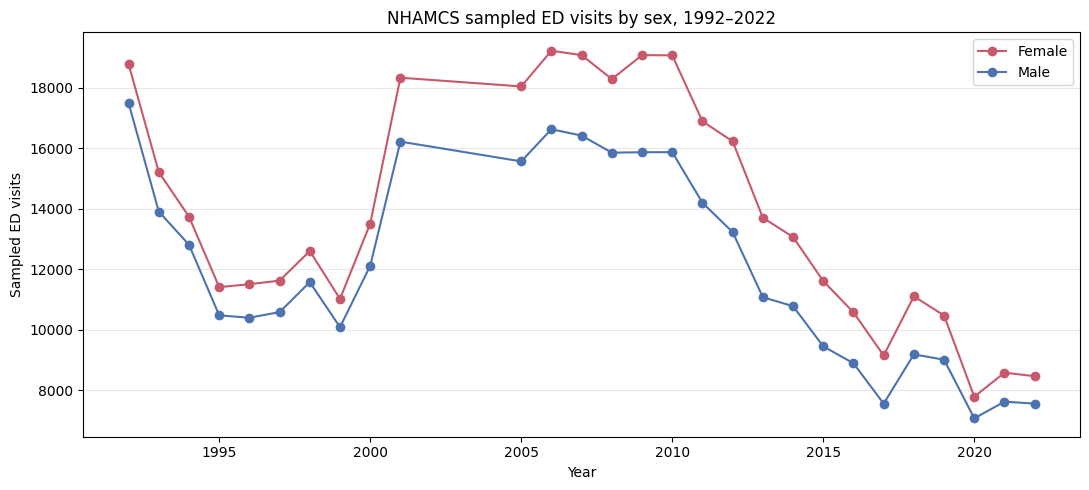

In [9]:
visits_by_year_sex = (
    data.dropna(subset=["sex_label"])
    .groupby(["YEAR", "sex_label"])
    .size()
    .unstack("sex_label")
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    visits_by_year_sex.index,
    visits_by_year_sex["Female"],
    color="#c8586c",
    marker="o",
    label="Female",
)
ax.plot(
    visits_by_year_sex.index,
    visits_by_year_sex["Male"],
    color="#4c72b0",
    marker="o",
    label="Male",
)
ax.set_xlabel("Year")
ax.set_ylabel("Sampled ED visits")
ax.set_title("NHAMCS sampled ED visits by sex, 1992–2022")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Plot — Median wait time by sex over time

Uses only years where `WAITTIME` is reliably populated.

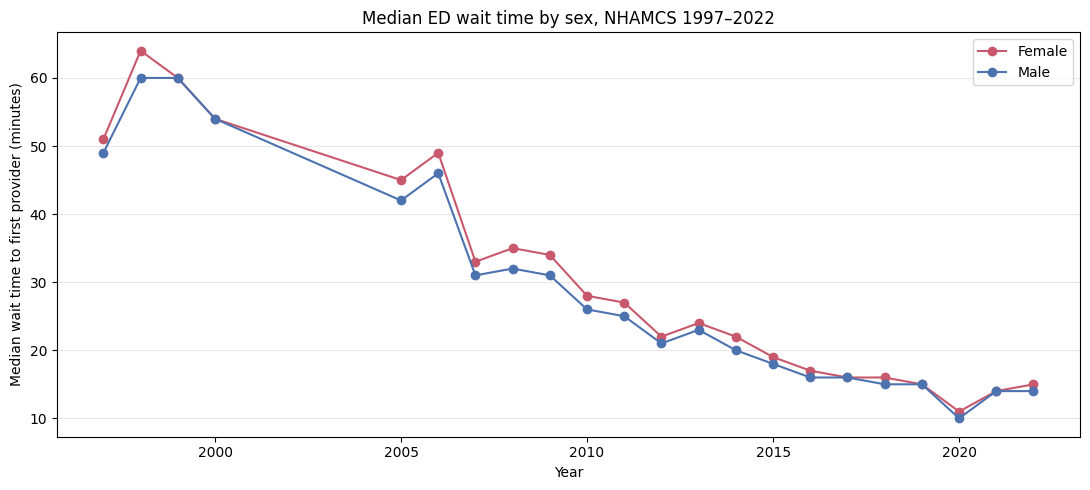

Female − Male wait gap by year (minutes):


,gap_min
YEAR,
1997,2.0
1998,4.0
1999,0.0
2000,0.0
2005,3.0
2006,3.0
2007,2.0
2008,3.0
2009,3.0


In [10]:
wait = data.dropna(subset=["WAITTIME", "sex_label"]).copy()
median_wait = (
    wait.groupby(["YEAR", "sex_label"])["WAITTIME"].median().unstack("sex_label")
)
median_wait = median_wait.dropna()  # drop years with no usable wait-time

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    median_wait.index,
    median_wait["Female"],
    color="#c8586c",
    marker="o",
    label="Female",
)
ax.plot(
    median_wait.index, median_wait["Male"], color="#4c72b0", marker="o", label="Male"
)
ax.set_xlabel("Year")
ax.set_ylabel("Median wait time to first provider (minutes)")
ax.set_title(
    f"Median ED wait time by sex, NHAMCS {median_wait.index.min()}–{median_wait.index.max()}"
)
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

gap = (median_wait["Female"] - median_wait["Male"]).round(1).to_frame("gap_min")
print("Female − Male wait gap by year (minutes):")
gap

## 6. Plot — Wait time by sex × triage acuity (2018–2022 pooled)

Controlling for triage acuity gives a fairer comparison than raw means. Restricted to the most recent years with stable `IMMEDR` coding.

Acuity codes: 1=Immediate, 2=Emergent, 3=Urgent, 4=Semi-urgent, 5=Non-urgent.

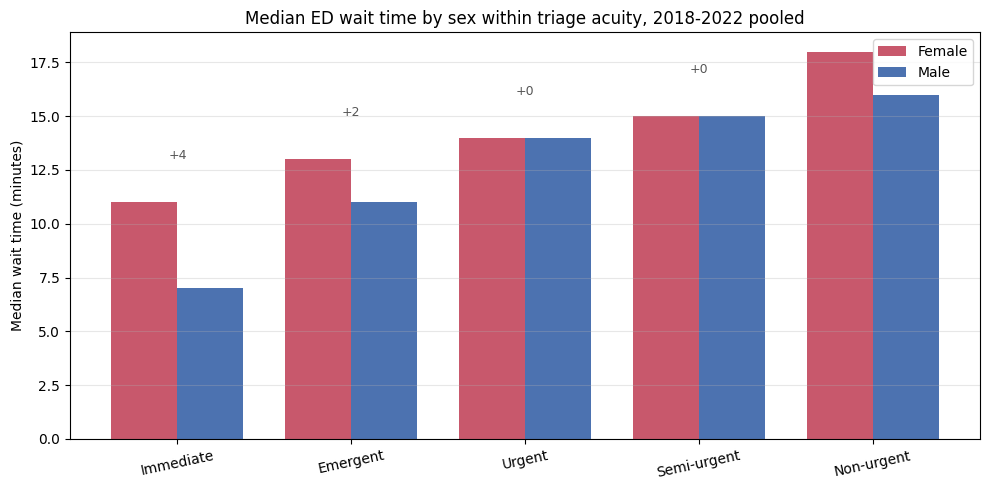

sex_label,Female,Male
acuity,,
Immediate,11.0,7.0
Emergent,13.0,11.0
Urgent,14.0,14.0
Semi-urgent,15.0,15.0
Non-urgent,18.0,16.0


In [11]:
acuity_labels = {
    1: "Immediate",
    2: "Emergent",
    3: "Urgent",
    4: "Semi-urgent",
    5: "Non-urgent",
}
order = list(acuity_labels.values())

recent = (
    wait[wait["YEAR"] >= 2018]
    .dropna(subset=["IMMEDR"])
    .assign(acuity=lambda d: d["IMMEDR"].map(acuity_labels))
    .dropna(subset=["acuity"])
)

pivot = (
    recent.groupby(["acuity", "sex_label"])["WAITTIME"]
    .median()
    .unstack("sex_label")
    .reindex(order)
)

female_vals = pivot["Female"].to_numpy()
male_vals = pivot["Male"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot))
w = 0.38
ax.bar(x - w / 2, female_vals, w, label="Female", color="#c8586c")
ax.bar(x + w / 2, male_vals, w, label="Male", color="#4c72b0")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=12)
ax.set_ylabel("Median wait time (minutes)")
ax.set_title("Median ED wait time by sex within triage acuity, 2018-2022 pooled")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for i, (f, m) in enumerate(zip(female_vals, male_vals)):
    if not (np.isnan(f) or np.isnan(m)):
        ax.annotate(
            f"{f - m:+.0f}", (i, max(f, m) + 2), ha="center", fontsize=9, color="#555"
        )

plt.tight_layout()
plt.show()
pivot

## Read

What this notebook confirms:
- All published NHAMCS Stata `.dta` files (1992–2001, 2005–2022) download and load.
- The stack works across 28 years, but column coverage varies — see the coverage table.
- A sex gap in median wait time appears in the raw sample and persists after controlling for triage acuity.

Not yet done (intentional for this first pass):
- Applying `PATWT` survey weights for true national estimates
- Narrowing to pain-related chief complaints
- Age and race/ethnicity controls
- Imaging and medication order rates by sex